<a href="https://colab.research.google.com/github/kat1478/nlp-semantic-similarity-bert/blob/main/Fine_tuning_BERT_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is focused on training a BERT-based model to evaluate the semantic similarity of question pairs using the Quora Question Pairs dataset. The notebook includes model initialization, training, and evaluation. Here's an outline of the steps:



1.   Model Setup:

*   Initializing the BERT model for sequence classification.
*   Configuring the optimizer (AdamW) and learning rate scheduler.


2.   Training:

*   Fine-tuning the model using the training dataset.
*   Performing validation to assess intermediate performance.


3. Evaluation:

*   Testing the model on unseen data.
*   Calculating metrics like accuracy, precision, recall, and F1-score.



Import and Initialize Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Install Required Libraries

In [3]:
!pip install transformers scikit-learn pandas

In [4]:
import pandas as pd
import json
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import torch


Load CSV and Tokenized Data

In [6]:
train_data = pd.read_csv('/content/drive/MyDrive/Output_bert/bert-base-uncased/train_data.csv')
val_data = pd.read_csv('/content/drive/MyDrive/Output_bert/bert-base-uncased/val_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Output_bert/bert-base-uncased/test_data.csv')

print(train_data.head())

       id    qid1    qid2                                      question1  \
0  175486  346687  346688  my video is monetizing but i have no reveanue   
1  128714  254975  254976              how will gst bill affect our life   
2  289456  568754  568755             why is education important to jews   
3  123353  244434  244435              what are 5 example of food chains   
4  216906  427677  427678                how can you lose weight quickly   

                                           question2  is_duplicate  
0  what can cause crying to be stunted when exper...             0  
1  what is gst tax and how much it would affect o...             1  
2    why are so many people fascinated with nonsense             0  
3                 what are 5 examples of food chains             1  
4      what is the easiest way to lose weight faster             1  


In [18]:
# Load tokenized JSON data
def load_tokenized_data(json_path):
    input_ids, attention_masks = [], []
    with open(json_path, 'r') as f:
        for line in f:
            item = json.loads(line)
            input_ids.append(torch.tensor(item['input_ids'][0]))
            attention_masks.append(torch.tensor(item['attention_mask'][0]))
    return input_ids, attention_masks

train_input_ids, train_attention_masks = load_tokenized_data('/content/drive/MyDrive/Output_bert/bert-base-uncased/train_tokens.json')
val_input_ids, val_attention_masks = load_tokenized_data('/content/drive/MyDrive/Output_bert/bert-base-uncased/val_tokens.json')
test_input_ids, test_attention_masks = load_tokenized_data('/content/drive/MyDrive/Output_bert/bert-base-uncased/test_tokens.json')

# Extract labels
train_labels = train_data['is_duplicate'].tolist()
val_labels = val_data['is_duplicate'].tolist()
test_labels = test_data['is_duplicate'].tolist()

print("Data loaded successfully.")

Data loaded successfully.


In [19]:
print(train_tokens[0])


{'input_ids': [[101, 2026, 2678, 2003, 12256, 20624, 6774, 2021, 1045, 2031, 2053, 7065, 11219, 5657, 102, 2054, 2064, 3426, 6933, 2000, 2022, 15412, 2098, 2043, 13417, 2022, 16416, 3726, 3672, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]}


Prepare DataLoader

In [20]:
# Function to prepare dataset
def prepare_data(input_ids, attention_masks, labels):
    return TensorDataset(
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.tensor(labels, dtype=torch.long)
    )

# Prepare datasets
train_dataset = prepare_data(train_input_ids, train_attention_masks, train_labels)
val_dataset = prepare_data(val_input_ids, val_attention_masks, val_labels)
test_dataset = prepare_data(test_input_ids, test_attention_masks, test_labels)

# Create DataLoaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_labels)}")
print(f"Validation samples: {len(val_labels)}")
print(f"Test samples: {len(test_labels)}")


Training samples: 323478
Validation samples: 40435
Test samples: 40435


Configure Model and Training Setup

In [21]:
from transformers import BertForSequenceClassification, AdamW, get_scheduler

# Define the device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Initialize the model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

# Configure the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Set up the scheduler
num_epochs = 3
num_training_steps = len(train_dataloader) * num_epochs
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

print("Model, optimizer, and scheduler configured.")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model, optimizer, and scheduler configured.


Train the Model

In [22]:
from tqdm import tqdm

def train_model(model, train_dataloader, val_dataloader, optimizer, scheduler, device, num_epochs):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        total_loss = 0
        for batch in tqdm(train_dataloader, desc="Training"):
            input_ids, attention_masks, labels = [item.to(device) for item in batch]
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_masks, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            scheduler.step()

        avg_loss = total_loss / len(train_dataloader)
        print(f"Training Loss: {avg_loss:.4f}")

        # Validation phase
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc="Validating"):
                input_ids, attention_masks, labels = [item.to(device) for item in batch]
                outputs = model(input_ids=input_ids, attention_mask=attention_masks)
                preds = torch.argmax(outputs.logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        accuracy = correct / total
        print(f"Validation Accuracy: {accuracy:.4f}")

train_model(model, train_dataloader, val_dataloader, optimizer, lr_scheduler, device, num_epochs)


Epoch 1/3


Training: 100%|██████████| 20218/20218 [1:52:12<00:00,  3.00it/s]


Training Loss: 0.3060


Validating: 100%|██████████| 2528/2528 [04:51<00:00,  8.68it/s]


Validation Accuracy: 0.8927
Epoch 2/3


...

Validation Accuracy: 0.9030
Epoch 3/3


Training: 100%|██████████| 20218/20218 [1:52:15<00:00,  3.00it/s]


Training Loss: 0.1033


Validating: 100%|██████████| 2528/2528 [04:51<00:00,  8.68it/s]

Validation Accuracy: 0.9079


Save Model After Training

In [24]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model.save_pretrained("/content/drive/MyDrive/bert_model_after_training")
tokenizer.save_pretrained("/content/drive/MyDrive/bert_model_after_training")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

('/content/drive/MyDrive/bert_model_after_training/tokenizer_config.json',
 '/content/drive/MyDrive/bert_model_after_training/special_tokens_map.json',
 '/content/drive/MyDrive/bert_model_after_training/vocab.txt',
 '/content/drive/MyDrive/bert_model_after_training/added_tokens.json')

In [25]:
save_directory = "/content/drive/MyDrive/Output_bert/bert-base-uncased-trained"
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)


('/content/drive/MyDrive/Output_bert/bert-base-uncased-trained/tokenizer_config.json',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-trained/special_tokens_map.json',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-trained/vocab.txt',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-trained/added_tokens.json')

Evaluate the Model on Test Data

In [26]:
def evaluate_model(model, test_dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Testing"):
            input_ids, attention_masks, labels = [item.to(device) for item in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_masks)
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

evaluate_model(model, test_dataloader, device)


Testing: 100%|██████████| 2528/2528 [04:44<00:00,  8.87it/s]

Test Accuracy: 0.9057


Save Model After Evaluate

In [27]:
save_directory = "/content/drive/MyDrive/Output_bert/bert-base-uncased-final"
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

('/content/drive/MyDrive/Output_bert/bert-base-uncased-final/tokenizer_config.json',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-final/special_tokens_map.json',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-final/vocab.txt',
 '/content/drive/MyDrive/Output_bert/bert-base-uncased-final/added_tokens.json')

Validation of the Code Against the Documented Requirements

               precision    recall  f1-score   support

Not Duplicate       0.93      0.91      0.92     25505
    Duplicate       0.86      0.89      0.87     14930

     accuracy                           0.91     40435
    macro avg       0.90      0.90      0.90     40435
 weighted avg       0.91      0.91      0.91     40435



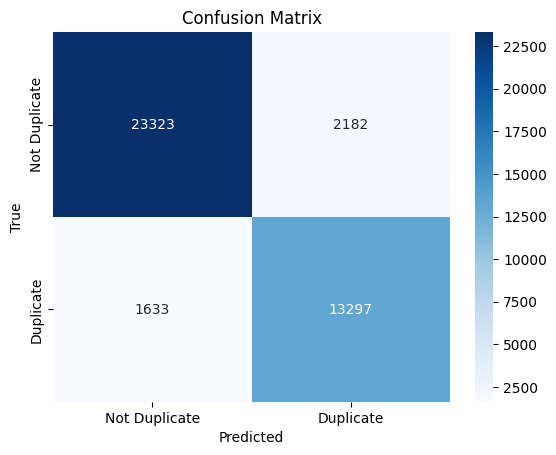

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions and labels
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_masks = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_masks)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
report = classification_report(all_labels, all_preds, target_names=["Not Duplicate", "Duplicate"])
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




Save classification report to a text file

Confusion matrix plot saved to /content/drive/MyDrive/Output_bert/confusion_matrix.png


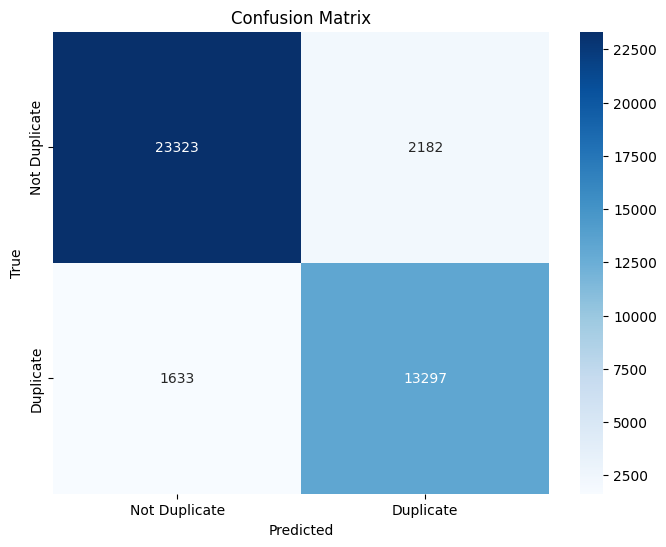

In [30]:
# Save classification report to a text file
with open('/content/drive/MyDrive/Output_bert/classification_report.txt', 'w') as f:
    f.write("Classification Report:\n")
    f.write(report)
# Save confusion matrix plot
cm_plot_path = '/content/drive/MyDrive/Output_bert/confusion_matrix.png'
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Duplicate", "Duplicate"],
            yticklabels=["Not Duplicate", "Duplicate"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(cm_plot_path)
print(f"Confusion matrix plot saved to {cm_plot_path}")


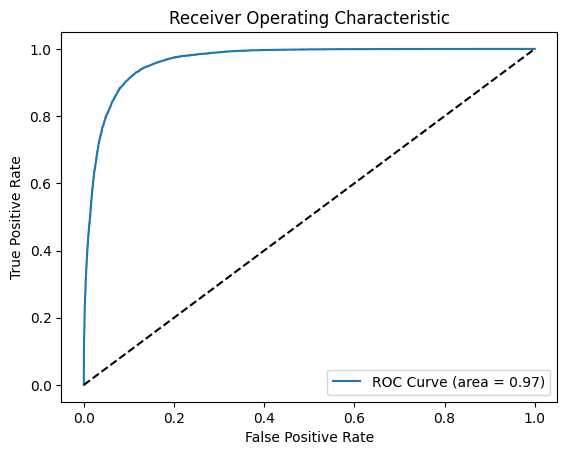

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predictions and labels
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_masks = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_masks)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]  # Probabilities for class 1
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


ROC curve plot saved to /content/drive/MyDrive/Output_bert/roc_curve.png


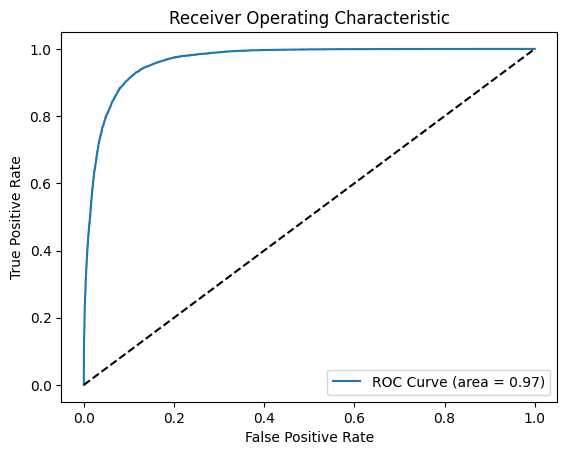

In [32]:
# Save ROC curve plot
roc_plot_path = '/content/drive/MyDrive/Output_bert/roc_curve.png'
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig(roc_plot_path)
print(f"ROC curve plot saved to {roc_plot_path}")


In [34]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Define the path to save the metrics summary
metrics_summary_path = '/content/drive/MyDrive/Output_bert/metrics_summary.txt'

# Save metrics summary
with open(metrics_summary_path, 'w') as f:
    f.write("Model Performance Summary:\n")
    f.write(f"Overall Accuracy: {accuracy_score(all_labels, all_preds):.4f}\n")
    f.write(f"F1-Score: {f1_score(all_labels, all_preds, average='weighted'):.4f}\n")
    f.write(f"ROC AUC: {roc_auc:.4f}\n")
print(f"Metrics summary saved to {metrics_summary_path}")


Metrics summary saved to /content/drive/MyDrive/Output_bert/metrics_summary.txt
